# Prediction markets on crypto prices: fair value, edges and hedges

**Research only.** This notebook reads public market data from Polymarket, Kalshi, Binance and Deribit. It places no
orders and uses no keys. Before any money goes near these venues, two things need checking outside this notebook:
whether your employer's personal-trading rules cover them, and whether each venue is open to Norwegian residents.

A market like "BTC above 84,600 at 6 PM" pays 1 if it happens and 0 if not, so its price is a probability. That makes
it a binary option, which can be priced, compared with other markets on the same question, and hedged.

The code is in `src/research/prediction_markets.py` (tests: `tests/test_prediction_markets.py`). Sections:

1. What is listed right now on both venues
2. The inputs: the BTC price and its short-term volatility
3. Fair value against the quotes, for the short markets
4. Longer markets: volatility from Deribit options, and the call-spread price of the same bet
5. The same question on two venues
6. Is the model any good? Calibration on 5 years of 5-minute data
7. The model against Kalshi's own quotes on settled markets
8. Hedging a binary with a perp
9. What to test next

In [1]:
import os, sys, warnings
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(ROOT)                                   # the data caches are addressed relative to the repo root
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.research import prediction_markets as pm
from src.utils.report import AXIS, SERIES, legend, style_axis
%matplotlib inline

pd.set_option("display.width", 220, "display.max_columns", 30, "display.float_format", lambda value: f"{value:,.4f}")
kalshi, polymarket = pm.KalshiClient(), pm.PolymarketClient()
now = pm.utc_now()
print("UTC now:", f"{now:%Y-%m-%d %H:%M:%S}")

UTC now: 2026-10-03 21:27:43


## 1. What is listed right now

Both venues list three shapes of BTC market: **above a level** at a time, **inside a range**, and **up or down**
over a window (15 minutes, an hour, four hours, a day). Quotes are probabilities between 0 and 1.

In [2]:
kalshi_markets = kalshi.price_markets("BTC", kinds=("above", "up_down"))
poly_markets = polymarket.price_markets("BTC")

def listing(markets):
    return pd.DataFrame([{"venue": m.venue, "kind": m.kind, "level": m.floor, "expires (UTC)": f"{m.expiry:%m-%d %H:%M}", "yes_bid": m.yes_bid, "yes_ask": m.yes_ask,
                          "fee_rate": m.fee_rate, "volume": m.volume, "market": m.market_id} for m in markets])

print(f"Kalshi: {len(kalshi_markets)} open BTC markets; Polymarket: {len(poly_markets)}")
quoted = [m for m in kalshi_markets if m.yes_bid and m.yes_ask and 0.03 < m.mid < 0.97]
display(listing(sorted(quoted, key=lambda m: -m.volume)[:10]))
display(listing([m for m in poly_markets if m.yes_bid and m.yes_ask][:12]))

Kalshi: 201 open BTC markets; Polymarket: 117


,venue,kind,level,expires (UTC),yes_bid,yes_ask,fee_rate,volume,market
0,kalshi,up_down,"84,670.3900",10-03 21:30,0.9540,0.9550,0.0700,"1,311,866.6900",KXBTC15M-26OCT031730-30
1,kalshi,above,"84,599.9900",10-03 22:00,0.8800,0.8900,0.0700,"179,774.2600",KXBTCD-26OCT0318-T84599.99
2,kalshi,above,"84,699.9900",10-03 22:00,0.5400,0.5500,0.0700,"141,317.6900",KXBTCD-26OCT0318-T84699.99
3,kalshi,above,"84,799.9900",10-03 22:00,0.1300,0.1400,0.0700,"96,774.1300",KXBTCD-26OCT0318-T84799.99
4,kalshi,above,"84,749.9900",10-04 21:00,0.4700,0.4800,0.0700,"20,908.7400",KXBTCD-26OCT0417-T84749.99
5,kalshi,above,"84,999.9900",10-04 21:00,0.3300,0.3400,0.0700,"14,338.9800",KXBTCD-26OCT0417-T84999.99
6,kalshi,above,"84,499.9900",10-04 21:00,0.6100,0.6200,0.0700,"10,045.5800",KXBTCD-26OCT0417-T84499.99
7,kalshi,above,"82,999.9900",10-04 21:00,0.9600,0.9700,0.0700,"5,771.0600",KXBTCD-26OCT0417-T82999.99
8,kalshi,above,"85,999.9900",10-04 21:00,0.0600,0.0700,0.0700,"5,026.2800",KXBTCD-26OCT0417-T85999.99
9,kalshi,above,"85,249.9900",10-04 21:00,0.2200,0.2300,0.0700,"4,625.8700",KXBTCD-26OCT0417-T85249.99


,venue,kind,level,expires (UTC),yes_bid,yes_ask,fee_rate,volume,market
0,polymarket,up_down,NaN,10-03 21:30,0.7600,0.7700,0.0700,"6,060.1012",btc-updown-15m-1791062100
1,polymarket,up_down,NaN,10-03 21:45,0.5100,0.5200,0.0700,"1,557.5702",btc-updown-15m-1791063000
2,polymarket,up_down,NaN,10-03 22:00,0.3600,0.3700,0.0700,"11,364.1925",bitcoin-up-or-down-october-3-2026-5pm-et
3,polymarket,up_down,NaN,10-03 22:00,0.4900,0.5000,0.0700,"1,375.1451",btc-updown-15m-1791063900
4,polymarket,above,"84,400.0000",10-03 22:00,0.9510,0.9980,0.0700,0.0000,bitcoin-above-84400-on-october-3-2026-6pm-et
5,polymarket,above,"84,600.0000",10-03 22:00,0.8700,0.9700,0.0700,0.0000,bitcoin-above-84600-on-october-3-2026-6pm-et
6,polymarket,above,"85,000.0000",10-03 22:00,0.0010,0.0500,0.0700,0.0000,bitcoin-above-85000-on-october-3-2026-6pm-et
7,polymarket,above,"85,200.0000",10-03 22:00,0.0010,0.0460,0.0700,0.0000,bitcoin-above-85200-on-october-3-2026-6pm-et
8,polymarket,above,"85,400.0000",10-03 22:00,0.0010,0.0450,0.0700,0.0000,bitcoin-above-85400-on-october-3-2026-6pm-et
9,polymarket,above,"85,600.0000",10-03 22:00,0.0010,0.0450,0.0700,0.0000,bitcoin-above-85600-on-october-3-2026-6pm-et


In [3]:
# What each venue settles on: this decides whether two markets are really the same bet
for market in (next(m for m in kalshi_markets if m.kind == "up_down"), next(m for m in poly_markets if m.kind == "up_down"), next((m for m in poly_markets if m.kind == "above"), None)):
    if market is not None:
        print(f"{market.venue:<11} {market.kind:<8} settles on: {market.settles_on[:170]}")

kalshi      up_down  settles on: If the simple average of the sixty seconds of CF Benchmarks' BRTI before 5:30 PM EDT on Oct 3, 2026 is at least the simple average of the sixty seconds of CF Benchmarks' 
polymarket  up_down  settles on: https://data.chain.link/streams/btc-usd-twap-60s-streams
polymarket  above    settles on: This market will resolve to "Yes" if the "Close" price for the BTC/USDT 1 hour candle that ends on the time and date specified in the title is higher than the price speci


## 2. The inputs: price and short-term volatility

The fair value of a short market depends almost entirely on how far the price is from the level, measured in
"expected moves" over the time left. So the one number that matters is volatility. For minutes-long markets it comes
from recent realized volatility: an exponentially weighted average of squared 1-minute returns.

BTCUSDT 84,696.32 at 21:28 UTC
{'half-life 15 min': '18% a year', 'half-life 60 min': '16% a year', 'half-life 240 min': '13% a year'}
One standard deviation over 15 minutes at 16%: 71 USD


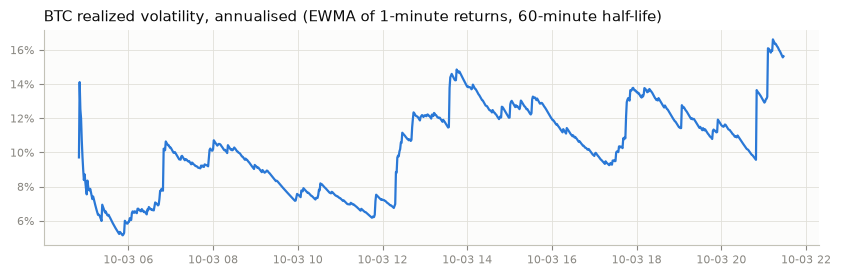

In [4]:
closes = pm.binance_closes("BTCUSDT", interval="1m", limit=1000)          # one public request, about 16 hours of minutes
spot = float(closes.iloc[-1])
vol = {f"half-life {h} min": pm.recent_volatility(closes, halflife_bars=h) for h in (15, 60, 240)}
sigma = vol["half-life 60 min"]
print(f"BTCUSDT {spot:,.2f} at {closes.index[-1]:%H:%M} UTC")
print({name: f"{value:.0%} a year" for name, value in vol.items()})
print(f"One standard deviation over 15 minutes at {sigma:.0%}: {spot * sigma * np.sqrt(900 / pm.SECONDS_PER_YEAR):,.0f} USD")

fig, ax = plt.subplots(figsize=(10, 2.8))
rolling = np.log(closes).diff().pow(2).ewm(halflife=60).mean().pipe(np.sqrt) * np.sqrt(pm.SECONDS_PER_YEAR / 60)
ax.plot(rolling.index, rolling, color=SERIES[0], linewidth=1.6)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
style_axis(ax, "BTC realized volatility, annualised (EWMA of 1-minute returns, 60-minute half-life)")
plt.show()

## 3. Fair value against the quotes: the short markets

`quote_table` gives, per market: the quotes, the model's probability, what **taking** either side at the ask would earn
after the taker fee (`edge_buy_yes`, `edge_buy_no`), and the perp position that would neutralise 100 contracts.

Two details matter here:

- **Kalshi settles on a different index** (CF Benchmarks' BRTI) than Binance's price. For the 15-minute market the
  level is the index at the window's start, so the model prices the *move*: the level times Binance's return since
  the window opened.
- **Polymarket's up/down markets don't publish their reference price.** It is the Chainlink (or Binance) price at
  the window's start. Binance's close at that minute stands in for it below; for a window that hasn't started,
  there is nothing to price yet.

Expect both edges to be negative most of the time. A fair value inside the spread means taking either side loses the
half-spread plus the fee, which is the market maker's income.

In [5]:
def with_binance_reference(market):
    """An up/down market priced on Binance's move since its window opened (None before the window starts)."""
    start = pd.Timestamp(market.start)
    if start > closes.index[-1] or start < closes.index[0]:
        return None, None
    opened = float(closes.asof(start))
    if market.floor is not None:                       # Kalshi: the level is on its own index; carry Binance's return over to it
        return market, market.floor * spot / opened
    return market.with_reference(opened), spot         # Polymarket: Binance's price at the start stands in for the reference

rows = []
for market in [m for m in kalshi_markets + poly_markets if m.kind == "up_down" and m.yes_ask]:
    priced, level_spot = with_binance_reference(market)
    if priced is not None:
        rows.append(pm.quote_table([priced], level_spot, sigma, now))
short = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display(short.drop(columns=["cap"], errors="ignore"))

,venue,market,kind,level,minutes_left,yes_bid,yes_ask,fair,edge_buy_yes,edge_buy_no,hedge_coins_per_100,volume
0,kalshi,KXBTC15M-26OCT031730-30,up_down,"84,670.3900",2.2711,0.9540,0.9550,0.6871,-0.2709,0.2638,-1.5322,"1,311,866.6900"
1,polymarket,btc-updown-15m-1791062100,up_down,"84,685.0400",2.2711,0.7600,0.7700,0.6871,-0.0952,0.0601,-1.5320,"6,060.1012"
2,polymarket,bitcoin-up-or-down-october-3-2026-5pm-et,up_down,"84,749.7500",32.2711,0.3600,0.3700,0.3030,-0.0833,0.0409,-0.3368,"11,364.1925"
3,polymarket,btc-updown-4h-1791057600,up_down,"84,842.5000",152.2711,0.2600,0.2700,0.2575,-0.0263,-0.0109,-0.1436,"8,007.3466"
4,polymarket,bitcoin-up-or-down-on-october-4-2026,up_down,"84,867.2800","1,112.2711",0.3900,0.4000,0.3881,-0.0287,-0.0148,-0.0629,"24,835.8401"


## 4. Longer markets: volatility from options, and the call-spread price

For markets that expire in hours or days, the options market has its own view of volatility. `chain_implied_vol`
reads it from a Deribit chain at the market's level and expiry. A binary above K is also the limit of a call spread
around K (long the call just below, short the call just above), so `call_spread_bounds` prices the same bet from
option quotes: what building it costs (`buy`) and what selling it earns (`sell`).

Deribit's expiries are at 08:00 UTC; Kalshi's daily markets close around 21:00-22:00 UTC and Polymarket's at 16:00 UTC.
The call spread is therefore for the nearest option expiry, 8 to 14 hours away, and its strikes are 500 to 1,000 USD
apart, so it is a wide ramp around the level, not a step at it. Read it as a rough cross-check, not a quote. Its
`buy` price can exceed 1 when the option quotes are wide.

In [6]:
from src.options.deribit import fetch_chain

chain = fetch_chain("BTC", now=now)                                           # one public request
print(f"{len(chain)} options, {chain['expiry'].nunique()} expiries; Deribit index {float(chain['index_price'].median()):,.0f} vs Binance spot {spot:,.0f}")

daily = [m for m in kalshi_markets + poly_markets if m.kind == "above" and m.yes_bid and m.yes_ask and 0.05 < m.mid < 0.95]
daily = sorted(daily, key=lambda m: (m.expiry, m.floor))[:14]
rows = []
for market in daily:
    implied = pm.chain_implied_vol(chain, market.floor, market.expiry, now=now)
    row = pm.quote_table([market], spot, implied, now).iloc[0].to_dict()
    spread = pm.call_spread_bounds(chain, market.floor, market.expiry)
    row.update({"implied_vol": implied, "expires (UTC)": f"{market.expiry:%m-%d %H:%M}"})
    if spread and spread["gap_hours"] <= 14:           # Deribit's dailies expire at 08:00 UTC: 8 to 14 hours from these markets
        row.update({"call_spread_sell": spread["sell"], "call_spread_mark": spread["mark"], "call_spread_buy": spread["buy"], "option_expiry": f"{spread['expiry']:%m-%d %H:%M}", "strikes": f"{spread['lower_strike']:,.0f}-{spread['upper_strike']:,.0f}"})
    rows.append(row)
longer = pd.DataFrame(rows)
columns = ["venue", "level", "expires (UTC)", "yes_bid", "yes_ask", "fair", "implied_vol", "edge_buy_yes", "edge_buy_no", "call_spread_sell", "call_spread_mark", "call_spread_buy", "option_expiry", "strikes"]
display(longer.reindex(columns=columns) if len(longer) else "No quoted 'above' markets between 5% and 95% right now.")

1002 options, 13 expiries; Deribit index 84,682 vs Binance spot 84,696


,venue,level,expires (UTC),yes_bid,yes_ask,fair,implied_vol,edge_buy_yes,edge_buy_no,call_spread_sell,call_spread_mark,call_spread_buy,option_expiry,strikes
0,kalshi,"84,599.9900",10-03 22:00,0.8800,0.8900,0.8259,0.1563,-0.0709,0.0467,0.3556,0.4156,0.5419,10-04 08:00,"84,500-85,000"
1,polymarket,"84,600.0000",10-03 22:00,0.8700,0.9700,0.8234,0.1563,-0.1486,0.0387,0.3556,0.4156,0.5419,10-04 08:00,"84,500-85,000"
2,kalshi,"84,699.9900",10-03 22:00,0.5400,0.5500,0.4856,0.1579,-0.0817,0.0370,0.3556,0.4156,0.5419,10-04 08:00,"84,500-85,000"
3,kalshi,"84,799.9900",10-03 22:00,0.1300,0.1400,0.1613,0.1596,0.0128,-0.0392,0.3556,0.4156,0.5419,10-04 08:00,"84,500-85,000"
4,polymarket,"84,000.0000",10-04 16:00,0.8540,0.8550,0.7941,0.2173,-0.0695,0.0511,0.4403,0.8611,1.2531,10-04 08:00,"84,000-84,500"
5,kalshi,"83,499.9900",10-04 21:00,0.9100,0.9200,0.8645,0.2480,-0.0607,0.0398,0.2540,0.9048,1.5242,10-05 08:00,"83,000-83,500"
6,kalshi,"83,749.9900",10-04 21:00,0.8900,0.9000,0.8212,0.2342,-0.0851,0.0620,0.1694,0.8327,1.4395,10-05 08:00,"83,500-84,000"
7,kalshi,"83,999.9900",10-04 21:00,0.8300,0.8400,0.7632,0.2206,-0.0863,0.0570,0.1694,0.8327,1.4395,10-05 08:00,"83,500-84,000"
8,kalshi,"84,249.9900",10-04 21:00,0.7400,0.7500,0.6833,0.2114,-0.0798,0.0432,0.3387,0.6842,1.1008,10-05 08:00,"84,000-84,500"
9,kalshi,"84,499.9900",10-04 21:00,0.6100,0.6200,0.5855,0.2025,-0.0510,0.0079,0.3387,0.6842,1.1008,10-05 08:00,"84,000-84,500"


## 5. The same question on two venues

If Kalshi and Polymarket list the same level at the same time, buying Yes on one and No on the other costs less than 1
when the two disagree by more than the fees. `match_markets` pairs them and `locked_edge` prices the pair.

It is only truly locked if both settle on the same number. They don't: different price sources, different averaging.
Near the level that difference decides the outcome, so a small positive number here is basis risk, not free money.

In [7]:
two_sided = lambda markets: [m for m in markets if m.yes_bid and m.yes_ask]
pairs = pm.match_markets(two_sided(kalshi_markets), two_sided(poly_markets), strike_tolerance=0.0005, minutes_tolerance=30)   # the same level to within 0.05%
if pairs:
    table = pd.DataFrame([{"level_kalshi": a.floor, "level_polymarket": b.floor, "expiry (UTC)": f"{a.expiry:%m-%d %H:%M}", "kalshi yes": f"{a.yes_bid:.2f}/{a.yes_ask:.2f}",
                           "polymarket yes": f"{b.yes_bid:.2f}/{b.yes_ask:.2f}", "mid_gap": a.mid - b.mid, "locked_edge": pm.locked_edge(a, b)} for a, b in pairs])
    display(table.sort_values("locked_edge", ascending=False).head(15))
else:
    k_times = sorted({m.expiry for m in kalshi_markets if m.kind == "above"})[:4]
    p_times = sorted({m.expiry for m in poly_markets if m.kind == "above"})[:4]
    print("No pair within 0.3% of level and 30 minutes of expiry right now.")
    print("Kalshi 'above' expiries (UTC):    ", [f"{t:%m-%d %H:%M}" for t in k_times])
    print("Polymarket 'above' expiries (UTC):", [f"{t:%m-%d %H:%M}" for t in p_times])

,level_kalshi,level_polymarket,expiry (UTC),kalshi yes,polymarket yes,mid_gap,locked_edge
0,"84,399.9900","84,400.0000",10-03 22:00,0.98/0.99,0.95/1.00,0.0105,-0.0195
2,"84,999.9900","85,000.0000",10-03 22:00,0.01/0.02,0.00/0.05,-0.0105,-0.0204
3,"85,199.9900","85,200.0000",10-03 22:00,0.01/0.02,0.00/0.05,-0.0085,-0.0204
1,"84,599.9900","84,600.0000",10-03 22:00,0.88/0.89,0.87/0.97,-0.0350,-0.0348


## 6. Is the model any good? Calibration on history

Before comparing the model with any market, check it against outcomes. On the cached Binance 5-minute BTC perp
candles (2021 to 2025; the 2026 holdout stays locked), every 15-minute and 1-hour window is an "up or down" question.
Partway through each window the model gives a probability from the move so far and a volatility estimated from the
past only. Calibrated means: of the times it said 70%, about 70% happened.

Set `LOG_TRIALS = True` once when a run is meant to count; it adds the configurations to the research trial ledger.

In [8]:
from src.research import governance, pit

LOG_TRIALS = False
bars = pit.load_bars("BTC", "5m")                                              # cached; holdout-locked
history = bars["close"].astype(float)
print(f"{len(history):,} five-minute closes, {history.index[0]:%Y-%m-%d} to {history.index[-1]:%Y-%m-%d}")

results = {"15-minute windows": pm.backtest_updown_model(history, window_bars=3), "1-hour windows": pm.backtest_updown_model(history, window_bars=12)}
tables = {name: pm.calibration_table(frame["prob"], frame["up"]) for name, frame in results.items()}
for name, table in tables.items():
    print(f"\n{name}: {len(results[name]):,} forecasts, Brier {table.attrs['brier']:.4f} (a coin flip scores 0.2500), log loss {table.attrs['log_loss']:.4f}")
    display(table)
if LOG_TRIALS:
    governance.record_trials("prediction_markets_calibration", len(results), family="prediction_markets", data="binance 5m BTC perp to 2025-12-31",
                             details={"model": "N(d2), EWMA volatility half-life 288 bars", "windows": list(results)})

508,895 five-minute closes, 2021-03-01 to 2025-12-31



15-minute windows: 339,070 forecasts, Brier 0.1726 (a coin flip scores 0.2500), log loss 0.5186


,forecasts,forecast,happened
bucket,,,
0%-10%,24352,0.0386,0.0495
10%-20%,21587,0.1522,0.1173
20%-30%,29998,0.2529,0.1944
30%-40%,41582,0.3525,0.2887
40%-50%,52048,0.4514,0.4179
50%-60%,51257,0.5487,0.5759
60%-70%,41291,0.6477,0.7152
70%-80%,29963,0.7476,0.8091
80%-90%,22276,0.8476,0.8869



1-hour windows: 466,213 forecasts, Brier 0.1653 (a coin flip scores 0.2500), log loss 0.4946


,forecasts,forecast,happened
bucket,,,
0%-10%,41645,0.0306,0.0280
10%-20%,25314,0.1516,0.0991
20%-30%,34968,0.2528,0.1813
30%-40%,52342,0.3536,0.2899
40%-50%,77534,0.4524,0.4261
50%-60%,76751,0.5475,0.5783
60%-70%,52473,0.6462,0.7165
70%-80%,35487,0.7473,0.8239
80%-90%,26696,0.8482,0.9045


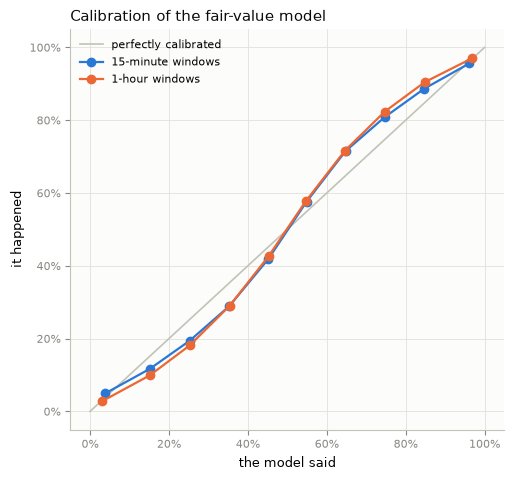

,forecasts,brier,"said >80%, happened"
time,,,
2021,"58,560.0000",0.1724,0.9333
2022,"70,080.0000",0.1708,0.9278
2023,"70,080.0000",0.1735,0.9260
2024,"70,272.0000",0.1724,0.9203
2025,"70,078.0000",0.1740,0.9113


,brier,log_loss
volatility x 0.7,0.1617,0.5064
volatility x 0.85,0.1622,0.4990
volatility x 1,0.1640,0.5003
volatility x 1.15,0.1664,0.5053
volatility x 1.3,0.1691,0.5119


In [9]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2, label="perfectly calibrated")
for (name, table), color in zip(tables.items(), SERIES):
    ax.plot(table["forecast"], table["happened"], "o-", color=color, linewidth=1.6, markersize=6, label=name)
ax.set_xlabel("the model said", fontsize=9); ax.set_ylabel("it happened", fontsize=9)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}"); ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
style_axis(ax, "Calibration of the fair-value model")
ax.legend(frameon=False, fontsize=8, loc="upper left")   # the points hug the diagonal, so this corner is empty
plt.show()

# Does it hold year by year, and does the volatility estimate carry the right scale?
frame = results["15-minute windows"]
by_year = frame.groupby(frame["time"].dt.year).apply(lambda part: pd.Series({"forecasts": len(part), "brier": float(((part["prob"] - part["up"]) ** 2).mean()),
                                                                              "said >80%, happened": float(part.loc[part["prob"] > 0.8, "up"].mean())}))
display(by_year)
scale = pd.DataFrame({f"volatility x {s:g}": pm.calibration_table(pm.backtest_updown_model(history.iloc[-120_000:], window_bars=3, vol_scale=s)["prob"],
                                                                 pm.backtest_updown_model(history.iloc[-120_000:], window_bars=3)["up"]).attrs for s in (0.7, 0.85, 1.0, 1.15, 1.3)}).T
display(scale)

**What the history shows** (2021 to 2025, about 340,000 and 470,000 forecasts):

- The model carries real information: its Brier score is about 0.17 against 0.25 for a coin flip, every year.
- It is **underconfident in the middle**. When it says 60-70% the event happens about 72% of the time; when it says
  30-40%, about 29%. The volatility estimate is an average dominated by a few violent bars, so in an ordinary window
  the price moves less than the model assumes. Scaling volatility by about 0.85 gives the best log loss on the last
  120,000 bars.
- Near 0% and 100% it is about right.

So a gap between this model and a market is not an edge by itself: part of it is this known bias.

## 7. The model against Kalshi's own quotes

The real test: on Kalshi's recently settled 15-minute markets, how far was the model from the market's midpoint
minute by minute, and which was closer to what happened? This uses a few dozen markets, so it is a first look, not
evidence. A proper study needs weeks of markets, a pre-registration, and the trial ledger.

On the first run (2026-10-03, 30 markets, 420 market-minutes) Kalshi's midpoint was closer to the outcomes than the
model: Brier 0.124 against 0.142. That is the expected result. The market sees the settlement index itself, order
flow, and second-by-second prices; this model sees Binance's 1-minute closes.

30 settled markets, 420 market-minutes


,minutes,mean_gap,mean_abs_gap,mean_spread
minutes_left,,,,
"(0, 3]",90,-0.0414,0.0823,0.0032
"(3, 7]",120,-0.0123,0.0765,0.0063
"(7, 11]",120,-0.0026,0.0683,0.0084
"(11, 15]",90,-0.0179,0.0685,0.0099


,brier,log_loss
model,0.1418,0.4351
kalshi midpoint,0.1240,0.3828


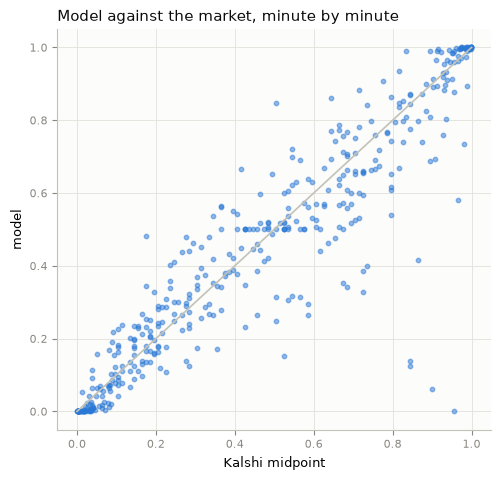

In [10]:
recent = pm.binance_closes("BTCUSDT", interval="1m", limit=1000)
versus = pm.kalshi_model_vs_market(kalshi, recent, markets=30)                 # one request per market
print(f"{versus['ticker'].nunique()} settled markets, {len(versus)} market-minutes")
versus["gap"] = versus["model"] - versus["market_mid"]
summary = versus.groupby(pd.cut(versus["minutes_left"], [0, 3, 7, 11, 15])).agg(minutes=("gap", "size"), mean_gap=("gap", "mean"), mean_abs_gap=("gap", lambda g: g.abs().mean()),
                                                                               mean_spread=("spread", "mean"))
display(summary)
scores = pd.DataFrame({"model": pm.calibration_table(versus["model"], versus["yes"]).attrs, "kalshi midpoint": pm.calibration_table(versus["market_mid"], versus["yes"]).attrs}).T
display(scores)

fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2)
ax.scatter(versus["market_mid"], versus["model"], s=10, color=SERIES[0], alpha=0.5)
ax.set_xlabel("Kalshi midpoint", fontsize=9); ax.set_ylabel("model", fontsize=9)
style_axis(ax, "Model against the market, minute by minute")
plt.show()

## 8. Hedging a binary with a perp

A Yes position gains when the price rises, so a short perp offsets it. `binary_delta` gives the size. The table
reprices 100 contracts and the hedge for a range of immediate moves. The hedge works for small moves and fails for
large ones: the binary can only ever gain `1 - price` or lose `price`, while the perp keeps moving. That shape is the
point of combining them: a binary can cap the loss on a perp position at a known cost, and a perp can remove the
direction from a binary bought because it looked cheap.

KXBTCD-26OCT0417-T84749.99: Yes above 84,750 at 10-04 21:00 UTC, quoted 0.47/0.48, model 0.474 at 20% volatility
Hedge for 100 contracts: -0.04472 BTC (-3,788 USD of perp against 47 USD of binary value)


,move,price,binary P&L,perp hedge P&L,together
0,-2.0%,"83,002.3900",-45.0500,75.7500,30.7100
1,-1.0%,"83,849.3600",-32.0400,37.8800,5.8300
2,-0.5%,"84,272.8400",-18.0100,18.9400,0.9300
3,-0.2%,"84,526.9300",-7.4900,7.5800,0.0800
4,+0.0%,"84,696.3200",0.0000,-0.0000,0.0000
5,+0.2%,"84,865.7100",7.5700,-7.5800,-0.0100
6,+0.5%,"85,119.8000",18.4900,-18.9400,-0.4500
7,+1.0%,"85,543.2800",33.7000,-37.8800,-4.1700
8,+2.0%,"86,390.2500",49.1600,-75.7500,-26.5900


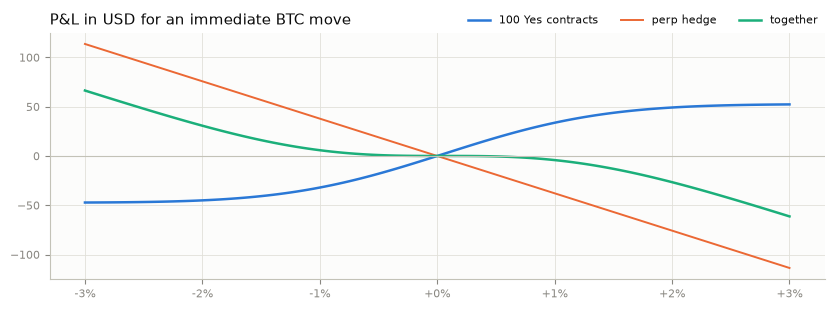

In [11]:
candidates = [m for m in kalshi_markets if m.kind == "above" and m.yes_bid and m.yes_ask and 0.25 < m.mid < 0.75 and (m.expiry - now).total_seconds() > 1800]
if candidates:
    market = min(candidates, key=lambda m: abs(m.mid - 0.5))
    vol_used = pm.chain_implied_vol(chain, market.floor, market.expiry, now=now)
    contracts = 100.0
    hedge = pm.hedge_units(market, spot, vol_used, now, contracts=contracts)
    base = pm.fair_value(market, spot, vol_used, now)
    print(f"{market.market_id}: Yes above {market.floor:,.0f} at {market.expiry:%m-%d %H:%M} UTC, quoted {market.yes_bid}/{market.yes_ask}, model {base:.3f} at {vol_used:.0%} volatility")
    print(f"Hedge for {contracts:.0f} contracts: {hedge:+.5f} BTC ({hedge * spot:+,.0f} USD of perp against {contracts * base:,.0f} USD of binary value)")
    moves = np.array([-0.02, -0.01, -0.005, -0.002, 0.0, 0.002, 0.005, 0.01, 0.02])
    table = pd.DataFrame({"move": moves, "price": spot * (1 + moves)})
    table["binary P&L"] = [contracts * (pm.fair_value(market, price, vol_used, now) - base) for price in table["price"]]
    table["perp hedge P&L"] = hedge * (table["price"] - spot)
    table["together"] = table["binary P&L"] + table["perp hedge P&L"]
    display(table.assign(move=table["move"].map("{:+.1%}".format)).round(2))

    fig, ax = plt.subplots(figsize=(10, 3.2))
    grid = np.linspace(-0.03, 0.03, 121)
    binary = np.array([contracts * (pm.fair_value(market, spot * (1 + g), vol_used, now) - base) for g in grid])
    ax.plot(grid, binary, color=SERIES[0], linewidth=1.8, label="100 Yes contracts")
    ax.plot(grid, hedge * spot * grid, color=SERIES[1], linewidth=1.4, label="perp hedge")
    ax.plot(grid, binary + hedge * spot * grid, color=SERIES[2], linewidth=1.8, label="together")
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:+.0%}")
    style_axis(ax, "P&L in USD for an immediate BTC move")
    legend(ax)
    plt.show()
else:
    print("No Kalshi 'above' market near 50% with more than 30 minutes left right now.")

## 9. What to test next

Each of these is a hypothesis. Write it down and lock it first (`python scripts/research/new_hypothesis.py new ...`),
so the rule isn't shaped by the result.

- **Model-versus-market gaps.** When the model and Kalshi's midpoint differ by more than the spread plus the fee, who
  is right? Section 7 is the method; it needs weeks of settled markets and a better volatility estimate at the
  1-minute scale (time of day matters, and so do jumps).
- **Options-implied versus quoted probability.** Do daily "above" markets sit systematically above or below what
  Deribit's smile implies? This needs the smile's slope added to the digital price, and matching expiries.
- **Binaries as cheap protection.** A perp long plus No contracts just below the price is a capped-loss position.
  Compare its cost with a Deribit put spread over the same hours.
- **Making instead of taking.** Section 3's edges are for taking. Quoting both sides earns the spread and Polymarket's
  maker rebate, at the price of being picked off when BTC jumps. It needs a simulation of fills, not a formula.
- **Favourite-longshot bias.** Are 2% and 98% quotes calibrated on these venues? Kalshi's settled markets with their
  candles are the data.

What this notebook cannot tell you: how fast the quotes move against a slow trader, or whether a quote you see can
actually be filled at size. Both venues' short markets are run by automated market makers faster than a 60-second loop.